# TASK 1 - Business Sales Performance Analytics
# Dataset : Superstore Sales Dataset
# Tool    : Python + Jupyter Notebook


# Section 1 - Import Libraries 

In [43]:
#  Import libraries 
import pandas as pd               # for data manipulation
import numpy as np                # for numerical operations
import matplotlib.pyplot as plt   # for basic charts
import seaborn as sns             # for beautiful statistical charts
import plotly.express as px       # for interactive charts
import warnings
warnings.filterwarnings('ignore')

#  Display settings 
pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places

print(" All libraries imported successfully!")

 All libraries imported successfully!


# Section 2 - Loading the Dataset and Checking the Dataset

In [45]:
# Load the dataset 
df = pd.read_csv("Sample Superstore.csv", encoding='latin-1')

print("Dataset loaded successfully!")
print(f"\n Shape of dataset : {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded successfully!

 Shape of dataset : 9994 rows × 21 columns


# SECTION 3 — Data Inspection & Cleaning Prep


In [47]:
#  Check data types and overall information 
print(" Dataset Info:")
df.info()

print("\n-----------------------------------------")

# Check for missing/blank values
print(" Missing Values in Each Column:")
print(df.isnull().sum())

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float6

# SECTION 3 — Data Cleaning & Formatting

In [49]:
# Convert Date columns to actual datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Drop 'Row ID' as it is unnecessary for our analysis
df = df.drop('Row ID', axis=1)

# Look at the basic statistics of our numerical columns
print(" Dates converted and Row ID dropped!")
print("\n Quick Statistical Summary:")
display(df[['Sales', 'Quantity', 'Discount', 'Profit']].describe())

 Dates converted and Row ID dropped!

 Quick Statistical Summary:


,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


# SECTION 4 — Business Question 1: Sales Trends Over Time

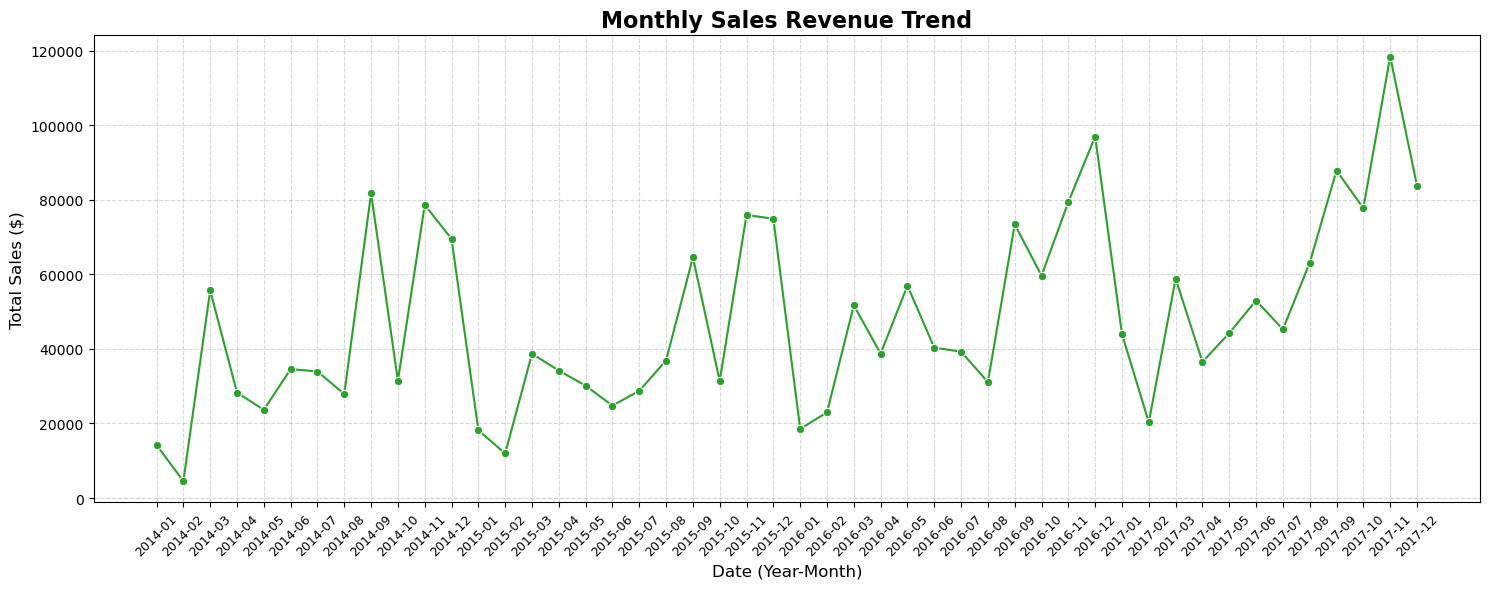

In [51]:
# 1. Extract Year and Month for our analysis
df['Year-Month'] = df['Order Date'].dt.to_period('M') # Groups them neatly into YYYY-MM

# 2. Calculate total sales for every single month
monthly_sales = df.groupby('Year-Month')['Sales'].sum().reset_index()
monthly_sales['Year-Month'] = monthly_sales['Year-Month'].astype(str) # Prep for charting

# 3. Build a professional trend chart
plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_sales, x='Year-Month', y='Sales', marker='o', color='#2ca02c')

# Formatting to make it client-ready
plt.title('Monthly Sales Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Date (Year-Month)', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45, fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the chart
plt.show()

# SECTION 5 — Business Question 2 & 3: Categories & Products

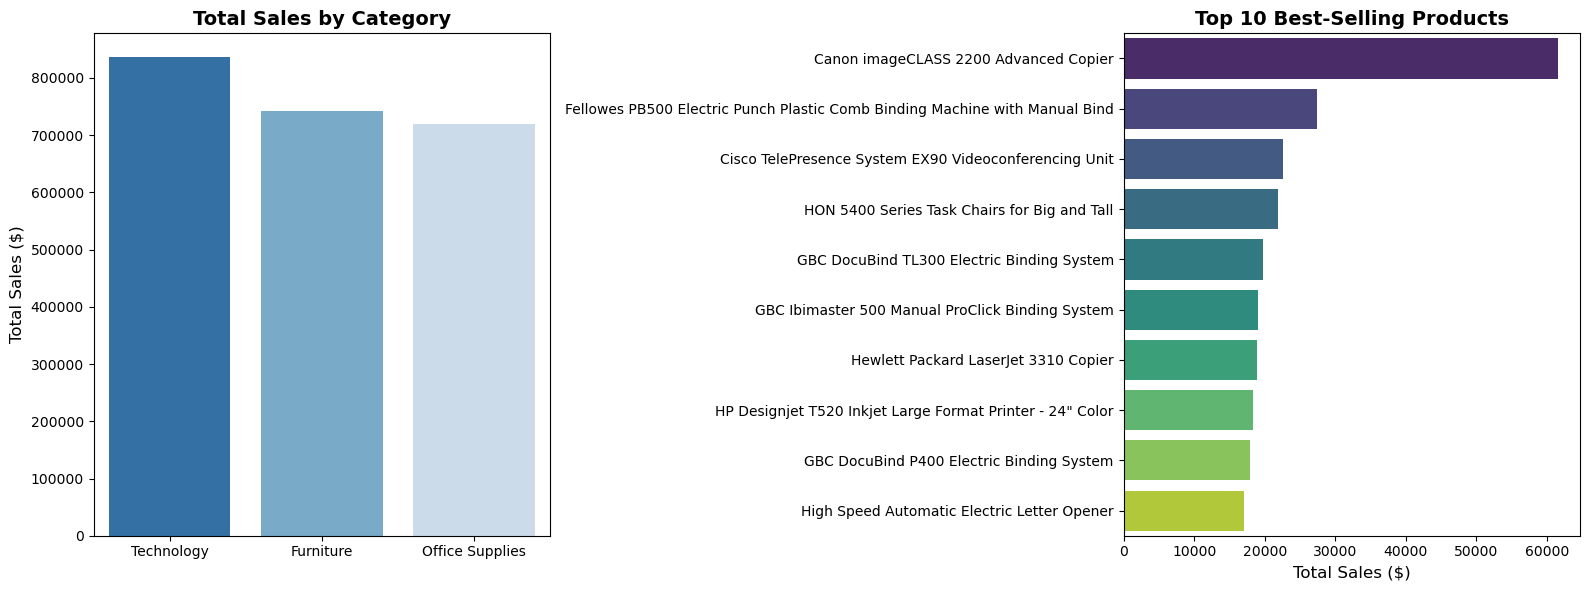

In [53]:
# Calculate total sales by Category
category_sales = df.groupby('Category')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)

# Calculate top 10 best-selling products
top_products = df.groupby('Product Name')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False).head(10)

# VISUALIZATION 
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Sales by Category
sns.barplot(data=category_sales, x='Category', y='Sales', palette='Blues_r', ax=ax[0])
ax[0].set_title('Total Sales by Category', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Total Sales ($)', fontsize=12)
ax[0].set_xlabel('', fontsize=12)

# Chart 2: Top 10 Products
sns.barplot(data=top_products, x='Sales', y='Product Name', palette='viridis', ax=ax[1])
ax[1].set_title('Top 10 Best-Selling Products', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Total Sales ($)', fontsize=12)
ax[1].set_ylabel('', fontsize=12)

# Show the charts cleanly
plt.tight_layout()
plt.show()

# SECTION 6 — Business Question 4: Regional Performance

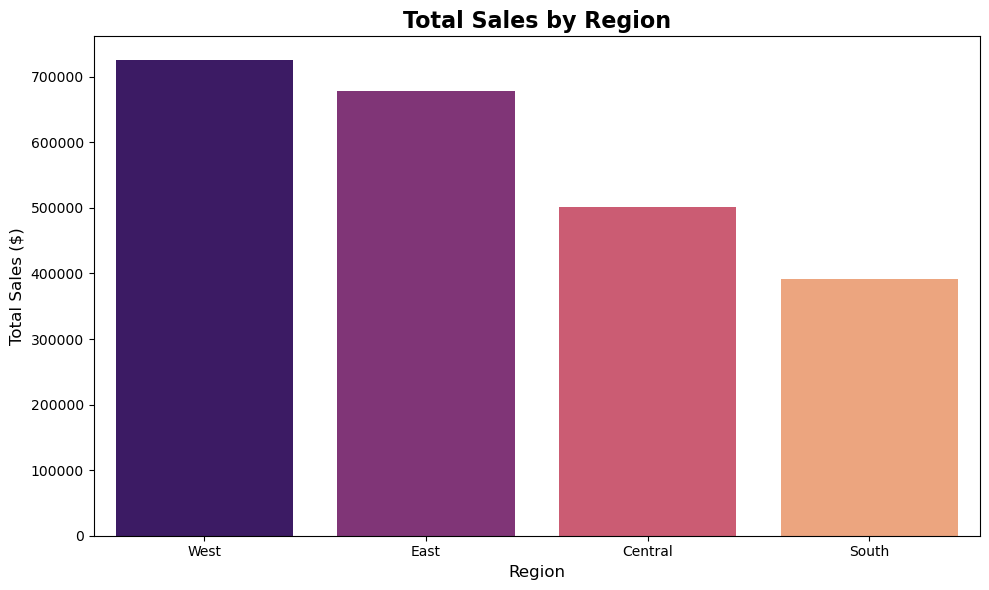

In [55]:
# Calculate total sales by Region
region_sales = df.groupby('Region')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)

# VISUALIZATION 
plt.figure(figsize=(10, 6))

# Build a bar chart for Regions
sns.barplot(data=region_sales, x='Region', y='Sales', palette='magma')

# Formatting
plt.title('Total Sales by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

# Show the chart
plt.tight_layout()
plt.show()

# Print the exact numbers to help with the final report

In [57]:
print("\n Exact Sales by Region:")
display(region_sales.style.format({'Sales': '${:,.2f}'}))


 Exact Sales by Region:


,Region,Sales
3,West,"$725,457.82"
1,East,"$678,781.24"
0,Central,"$501,239.89"
2,South,"$391,721.91"
